# Noise schedules and forward process visualization

This notebook visualizes the two noise schedules implemented in
`ddpm.diffusion.schedules` (linear and cosine), and shows the forward
process on a real FashionMNIST image to build intuition before
implementing the full Gaussian diffusion module.

In [2]:
from __future__ import annotations

import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms

from ddpm.diffusion.schedules import get_beta_schedule

# Sober matplotlib style for publication-grade figures
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

torch.manual_seed(0)

## 1. Compute both schedules

We instantiate both schedules with `T = 1000` and derive the quantities
that matter for the forward process: `alpha_t = 1 - beta_t` and
`alpha_bar_t = cumprod(alpha)`.

In [3]:
T = 1000

betas_lin = get_beta_schedule("linear", T)
betas_cos = get_beta_schedule("cosine", T)

alphas_bar_lin = torch.cumprod(1.0 - betas_lin, dim=0)
alphas_bar_cos = torch.cumprod(1.0 - betas_cos, dim=0)

print(f"Linear:  beta[0]={betas_lin[0]:.2e}, beta[-1]={betas_lin[-1]:.2e}")
print(f"Cosine:  beta[0]={betas_cos[0]:.2e}, beta[-1]={betas_cos[-1]:.2e}")
print(f"Linear:  alpha_bar[0]={alphas_bar_lin[0]:.4f}, alpha_bar[-1]={alphas_bar_lin[-1]:.2e}")
print(f"Cosine:  alpha_bar[0]={alphas_bar_cos[0]:.4f}, alpha_bar[-1]={alphas_bar_cos[-1]:.2e}")

Linear:  beta[0]=1.00e-04, beta[-1]=2.00e-02
Cosine:  beta[0]=4.13e-05, beta[-1]=9.99e-01
Linear:  alpha_bar[0]=0.9999, alpha_bar[-1]=4.04e-05
Cosine:  alpha_bar[0]=1.0000, alpha_bar[-1]=2.43e-09


## 2. Plot betas and signal/noise coefficients

Three views side by side:
- `beta_t`: noise added at each step.
- `alpha_bar_t`: signal kept since the original image.
- `sqrt(alpha_bar)` and `sqrt(1 - alpha_bar)`: the actual coefficients
  that show up in the forward formula `x_t = sqrt(ᾱ)·x_0 + sqrt(1-ᾱ)·ε`.

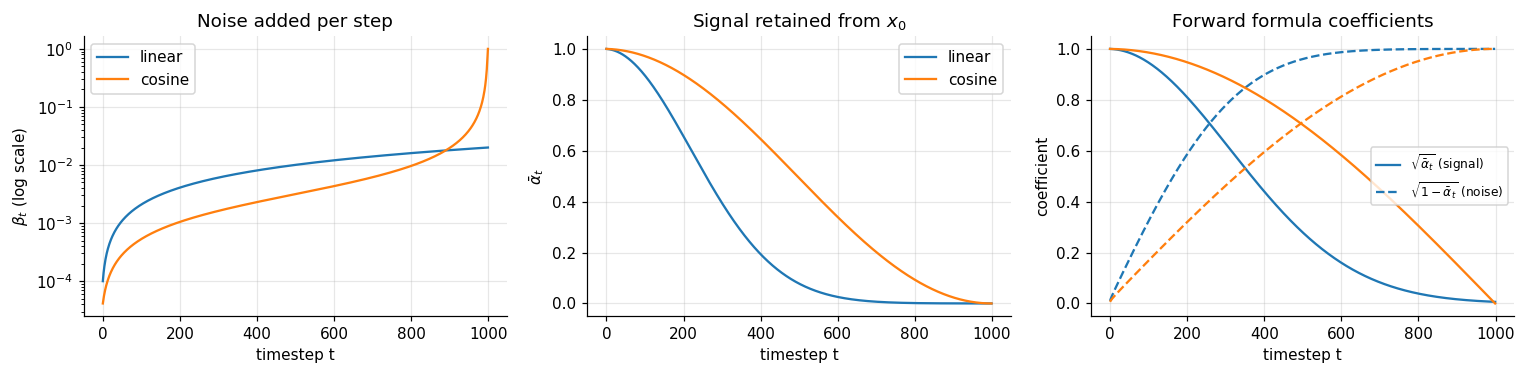

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
t = torch.arange(T)

# Left: betas
axes[0].plot(t, betas_lin, label="linear", color="tab:blue")
axes[0].plot(t, betas_cos, label="cosine", color="tab:orange")
axes[0].set_yscale("log")
axes[0].set_xlabel("timestep t")
axes[0].set_ylabel(r"$\beta_t$ (log scale)")
axes[0].set_title("Noise added per step")
axes[0].legend()

# Middle: alpha_bar
axes[1].plot(t, alphas_bar_lin, label="linear", color="tab:blue")
axes[1].plot(t, alphas_bar_cos, label="cosine", color="tab:orange")
axes[1].set_xlabel("timestep t")
axes[1].set_ylabel(r"$\bar{\alpha}_t$")
axes[1].set_title("Signal retained from $x_0$")
axes[1].legend()

# Right: sqrt coefficients (signal vs noise weight in x_t)
axes[2].plot(t, alphas_bar_lin.sqrt(), label=r"$\sqrt{\bar{\alpha}_t}$ (signal)", color="tab:blue")
axes[2].plot(t, (1 - alphas_bar_lin).sqrt(), label=r"$\sqrt{1-\bar{\alpha}_t}$ (noise)",
             color="tab:blue", linestyle="--")
axes[2].plot(t, alphas_bar_cos.sqrt(), color="tab:orange")
axes[2].plot(t, (1 - alphas_bar_cos).sqrt(), color="tab:orange", linestyle="--")
axes[2].set_xlabel("timestep t")
axes[2].set_ylabel("coefficient")
axes[2].set_title("Forward formula coefficients")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Forward process on a real image

We download one FashionMNIST sample, normalize it to `[-1, 1]`, and
apply `q_sample` at increasing timesteps to see how the image dissolves
into noise under each schedule.

In [7]:
# Download a single image (no need for the full dataset for this viz)
ds = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: 2 * x - 1),   # [0,1] -> [-1,1]
    ]),
)
x0, label = ds[7]
print(f"Image shape: {tuple(x0.shape)}, range: [{x0.min():.2f}, {x0.max():.2f}], class: {label}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 45.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.69MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 30.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 35.9MB/s]


Image shape: (1, 28, 28), range: [-1.00, 1.00], class: 2


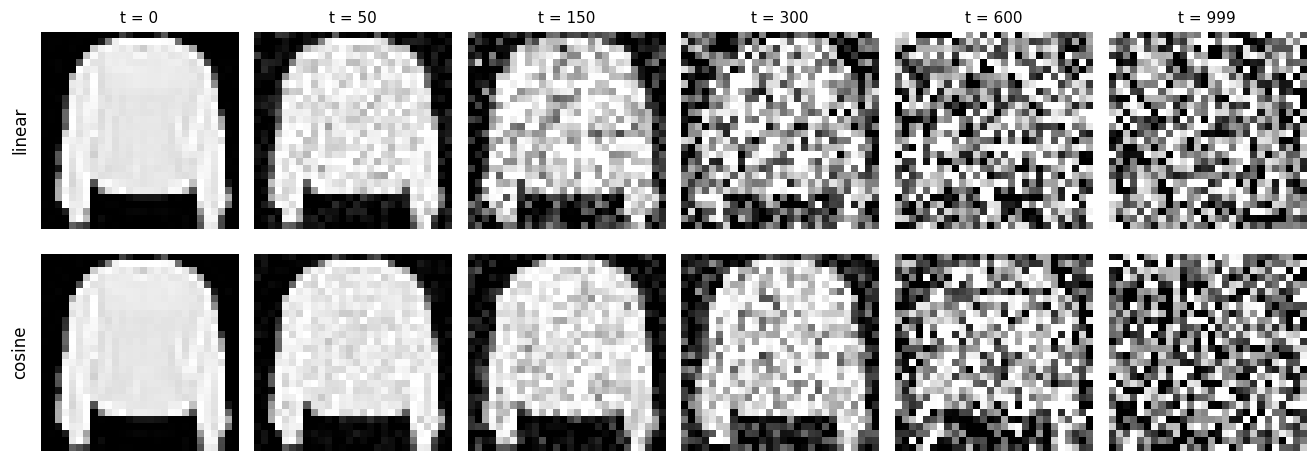

In [ ]:
def q_sample(x0: torch.Tensor, t: int, alphas_bar: torch.Tensor) -> torch.Tensor:
    """Apply the forward process at timestep t to a single image."""
    sqrt_ab = alphas_bar[t].sqrt()
    sqrt_1m_ab = (1.0 - alphas_bar[t]).sqrt()
    noise = torch.randn_like(x0)
    return sqrt_ab * x0 + sqrt_1m_ab * noise


timesteps_to_show = [0, 50, 150, 300, 600, 999]

fig, axes = plt.subplots(2, len(timesteps_to_show), figsize=(2 * len(timesteps_to_show), 4.5))

for col, t in enumerate(timesteps_to_show):
    for row, (alphas_bar, name) in enumerate([
        (alphas_bar_lin, "linear"),
        (alphas_bar_cos, "cosine"),
    ]):
        xt = q_sample(x0, t, alphas_bar)
        axes[row, col].imshow(xt.squeeze(), cmap="gray", vmin=-1, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t = {t}", fontsize=10)
        if col == 0:
            axes[row, col].text(-0.15, 0.5, name, transform=axes[row, col].transAxes,
                                rotation=90, va="center", fontsize=11)

plt.tight_layout()
plt.show()